Loading data files... (This may take a moment due to high sample rates)
Generating plots...


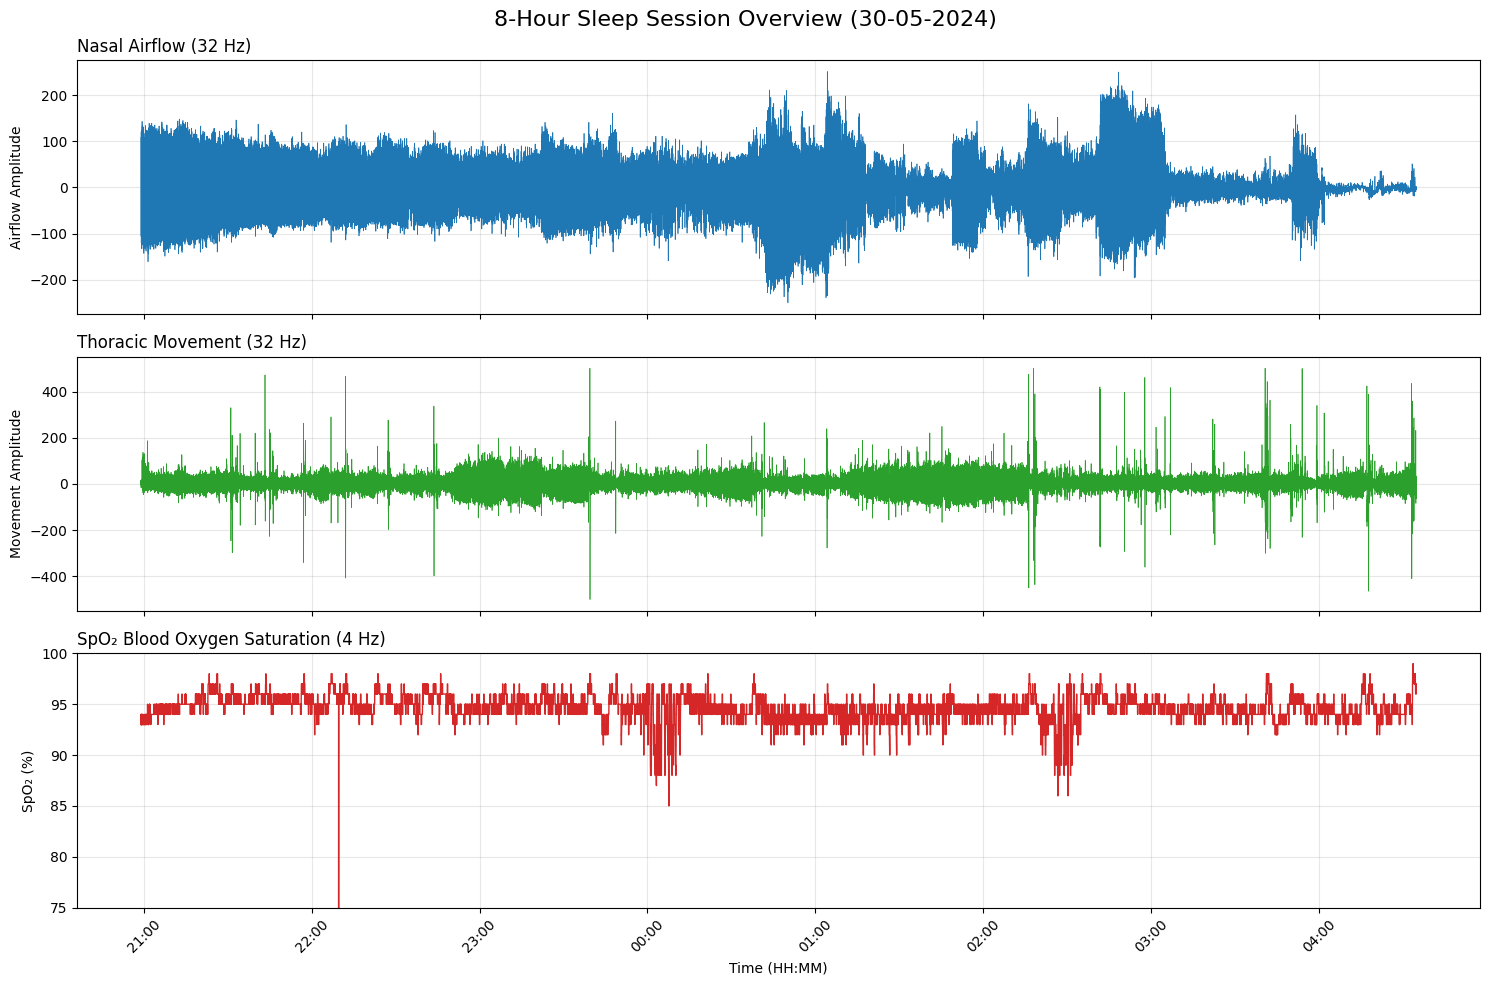

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

def load_and_parse_sleep_data(filepath):
    """
    Loads sleep signal data, skipping metadata headers,
    and parses the custom timestamp format.
    """
    # The data points start on line 8 (index 7) after the "Data:" header
    df = pd.read_csv(filepath, sep=';', skiprows=7, header=None, names=['timestamp', 'value'])

    # Clean up any trailing whitespace in timestamps
    df['timestamp'] = df['timestamp'].str.strip()

    # Parse the custom European datetime format with milliseconds (e.g., '30.05.2024 20:59:00,000')
    df['timestamp'] = pd.to_datetime(df['timestamp'], format='%d.%m.%Y %H:%M:%S,%f')

    # Downsample the data (optional but recommended for 8-hour plots to save memory)
    # df = df.iloc[::10, :] # Uncomment this to plot every 10th point if rendering is too slow

    return df

print("Loading data files... (This may take a moment due to high sample rates)")

# Load the participant's data
flow_df = load_and_parse_sleep_data('Flow - 30-05-2024.txt')
thorac_df = load_and_parse_sleep_data('Thorac - 30-05-2024.txt')
spo2_df = load_and_parse_sleep_data('SPO2 - 30-05-2024.txt')

print("Generating plots...")

# Create a 3-panel stacked plot sharing the same X-axis (Time)
fig, axs = plt.subplots(3, 1, figsize=(15, 10), sharex=True)
fig.suptitle('8-Hour Sleep Session Overview (30-05-2024)', fontsize=16)

# 1. Plot Nasal Airflow
axs[0].plot(flow_df['timestamp'], flow_df['value'], color='#1f77b4', linewidth=0.5)
axs[0].set_title('Nasal Airflow (32 Hz)', loc='left', fontsize=12)
axs[0].set_ylabel('Airflow Amplitude')
axs[0].grid(True, alpha=0.3)

# 2. Plot Thoracic Movement
axs[1].plot(thorac_df['timestamp'], thorac_df['value'], color='#2ca02c', linewidth=0.5)
axs[1].set_title('Thoracic Movement (32 Hz)', loc='left', fontsize=12)
axs[1].set_ylabel('Movement Amplitude')
axs[1].grid(True, alpha=0.3)

# 3. Plot SpO2
axs[2].plot(spo2_df['timestamp'], spo2_df['value'], color='#d62728', linewidth=1)
axs[2].set_title('SpO₂ Blood Oxygen Saturation (4 Hz)', loc='left', fontsize=12)
axs[2].set_ylabel('SpO₂ (%)')
axs[2].set_xlabel('Time (HH:MM)')
# Typical SpO2 ranges stay above 80%, setting limits helps spot desaturations easily
axs[2].set_ylim(75, 100)
axs[2].grid(True, alpha=0.3)

# Format the X-axis to cleanly show hours and minutes
axs[2].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.xticks(rotation=45)

# Adjust layout to prevent overlapping labels and display
plt.tight_layout()
plt.subplots_adjust(top=0.93)
plt.show()

डेटा लोड किया जा रहा है... (कृपया 1-2 मिनट प्रतीक्षा करें)
📊 ग्राफ तैयार किया जा रहा है...


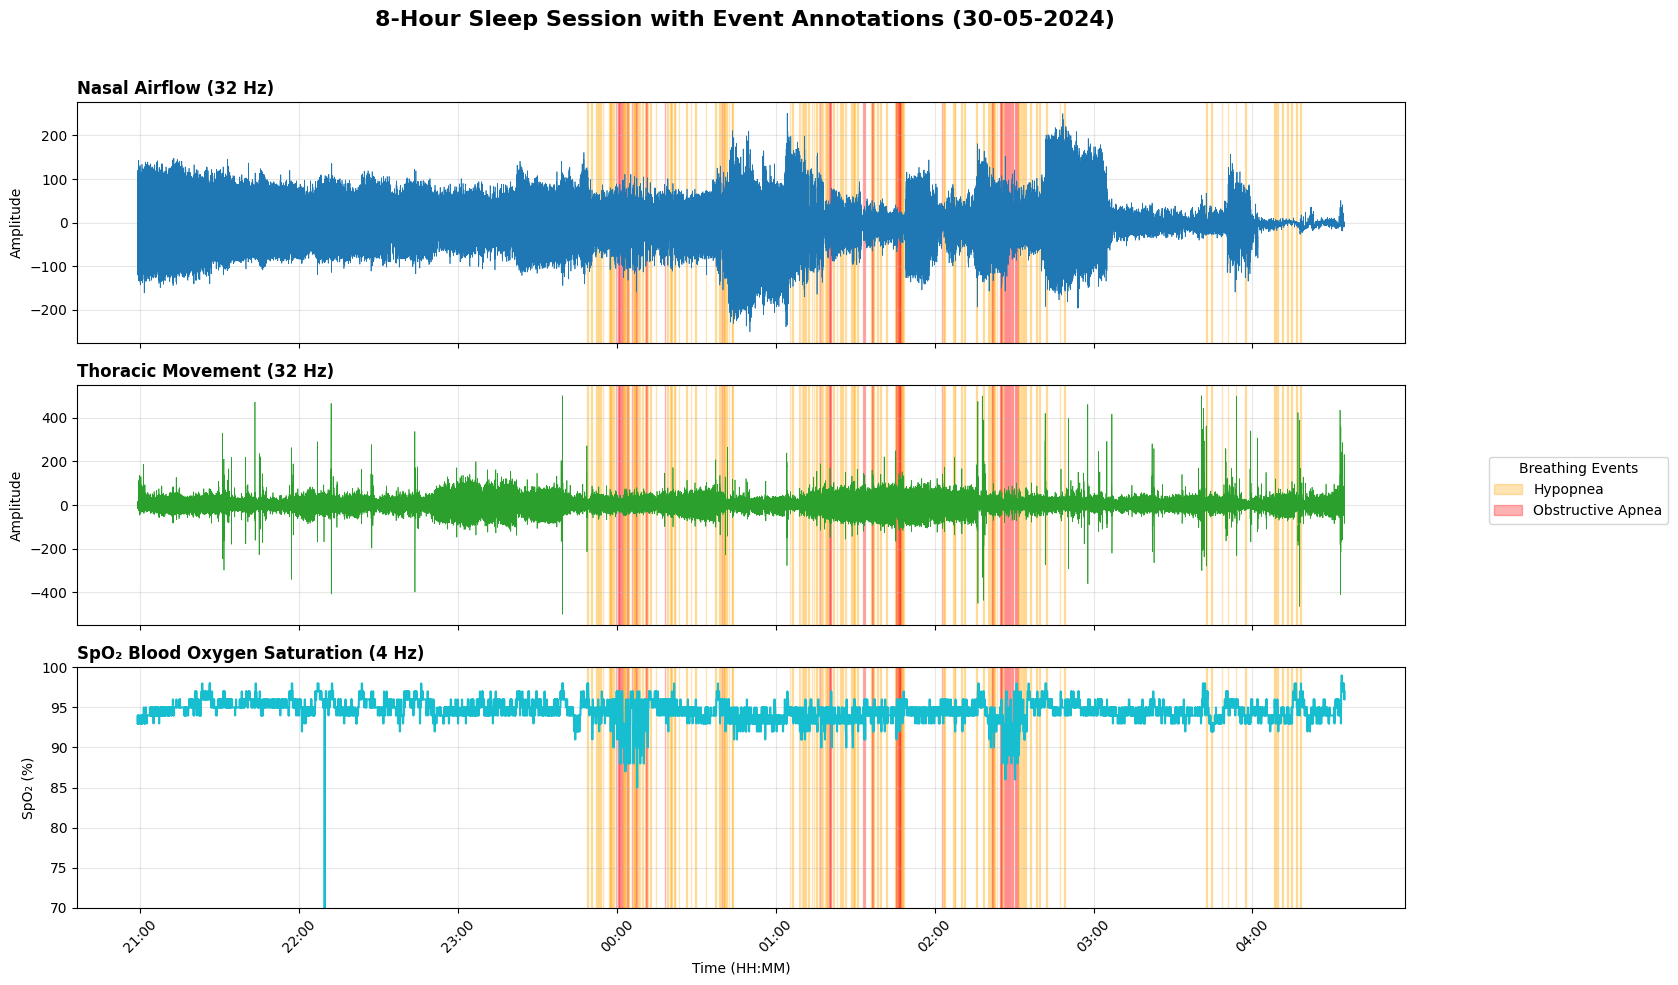

✅ प्रक्रिया पूरी हुई!


In [ ]:
# Step 1: Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os

print("डेटा लोड किया जा रहा है... (कृपया 1-2 मिनट प्रतीक्षा करें)")

# Check if files exist in the current directory
required_files = [
    'Flow - 30-05-2024.txt',
    'Thorac - 30-05-2024.txt',
    'SPO2 - 30-05-2024.txt',
    'Flow Events - 30-05-2024.txt'
]

missing_files = [f for f in required_files if not os.path.exists(f)]

if missing_files:
    print(f"⚠️ Error: ये फाइल्स नहीं मिलीं: {missing_files}")
    print("कृपया चेक करें कि आपने फाइल्स सही नाम से Colab के फाइल सेक्शन में अपलोड की हैं या नहीं।")
else:
    # Step 2: Continuous signal data (Flow, Thorac, SPO2) को प्रोसेस करने का फंक्शन
    def load_and_parse_sleep_data(filepath):
        df = pd.read_csv(filepath, sep=';', skiprows=7, header=None, names=['timestamp', 'value'])
        df['timestamp'] = df['timestamp'].str.strip()
        df['timestamp'] = pd.to_datetime(df['timestamp'], format='%d.%m.%Y %H:%M:%S,%f')

        # NOTE: अगर Colab का RAM फुल हो जाता है, तो नीचे वाली लाइन से '#' हटा दें (इससे डेटा हल्का हो जाएगा)
        # df = df.iloc[::5, :]
        return df

    # Step 3: स्लीप इवेंट्स (Apnea/Hypopnea) को प्रोसेस करने का फंक्शन
    def load_events_data(filepath):
        with open(filepath, 'r', encoding='utf-8') as f:
            lines = f.readlines()[5:]

        events = []
        for line in lines:
            if not line.strip(): continue
            parts = line.split(';')
            if len(parts) >= 3:
                time_part = parts[0].strip()
                event_type = parts[2].strip()

                date_start, end_time = time_part.split('-')
                start_dt_str = date_start.strip()

                date_str = start_dt_str.split(' ')[0]
                end_dt_str = f"{date_str} {end_time.strip()}"

                start_dt = pd.to_datetime(start_dt_str, format='%d.%m.%Y %H:%M:%S,%f')
                end_dt = pd.to_datetime(end_dt_str, format='%d.%m.%Y %H:%M:%S,%f')

                if end_dt < start_dt:
                    end_dt += pd.Timedelta(days=1)

                events.append({'start': start_dt, 'end': end_dt, 'type': event_type})
        return pd.DataFrame(events)

    # Step 4: डेटा फाइल्स को लोड करें
    flow_df = load_and_parse_sleep_data('Flow - 30-05-2024.txt')
    thorac_df = load_and_parse_sleep_data('Thorac - 30-05-2024.txt')
    spo2_df = load_and_parse_sleep_data('SPO2 - 30-05-2024.txt')
    events_df = load_events_data('Flow Events - 30-05-2024.txt')

    print("📊 ग्राफ तैयार किया जा रहा है...")

    # Step 5: ग्राफ बनाना (Plotting)
    fig, axs = plt.subplots(3, 1, figsize=(15, 10), sharex=True)
    fig.suptitle('8-Hour Sleep Session with Event Annotations (30-05-2024)', fontsize=16, fontweight='bold')

    # 1. Nasal Airflow
    axs[0].plot(flow_df['timestamp'], flow_df['value'], color='#1f77b4', linewidth=0.5)
    axs[0].set_title('Nasal Airflow (32 Hz)', loc='left', fontsize=12, fontweight='bold')
    axs[0].set_ylabel('Amplitude')
    axs[0].grid(True, alpha=0.3)

    # 2. Thoracic Movement
    axs[1].plot(thorac_df['timestamp'], thorac_df['value'], color='#2ca02c', linewidth=0.5)
    axs[1].set_title('Thoracic Movement (32 Hz)', loc='left', fontsize=12, fontweight='bold')
    axs[1].set_ylabel('Amplitude')
    axs[1].grid(True, alpha=0.3)

    # 3. SpO2
    axs[2].plot(spo2_df['timestamp'], spo2_df['value'], color='#17becf', linewidth=1.5)
    axs[2].set_title('SpO₂ Blood Oxygen Saturation (4 Hz)', loc='left', fontsize=12, fontweight='bold')
    axs[2].set_ylabel('SpO₂ (%)')
    axs[2].set_xlabel('Time (HH:MM)')
    axs[2].set_ylim(70, 100)
    axs[2].grid(True, alpha=0.3)

    # --- Events Overlay (कलर शेडिंग) ---
    event_colors = {
        'Obstructive Apnea': 'red',
        'Hypopnea': 'orange',
        'Central Apnea': 'purple',
        'Mixed Apnea': 'brown'
    }

    for ax in axs:
        for _, row in events_df.iterrows():
            event_color = event_colors.get(row['type'], 'gray')
            ax.axvspan(row['start'], row['end'], color=event_color, alpha=0.3, label=row['type'])

    # Time Format सही करना
    axs[2].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    plt.xticks(rotation=45)

    # Legend (इवेंट्स की पहचान के लिए बॉक्स)
    handles, labels = axs[0].get_legend_handles_labels()
    unique_labels = dict(zip(labels, handles))
    if unique_labels:
        fig.legend(unique_labels.values(), unique_labels.keys(), loc='center right', title="Breathing Events", bbox_to_anchor=(1.12, 0.5))

    # लेआउट को एडजस्ट करें ताकि सब कुछ साफ दिखे
    plt.tight_layout(rect=[0, 0, 0.95, 0.96])
    plt.show()
    print("✅ प्रक्रिया पूरी हुई!")

Loading data... (Please wait)
Applying digital filters...
Generating comparison plot...


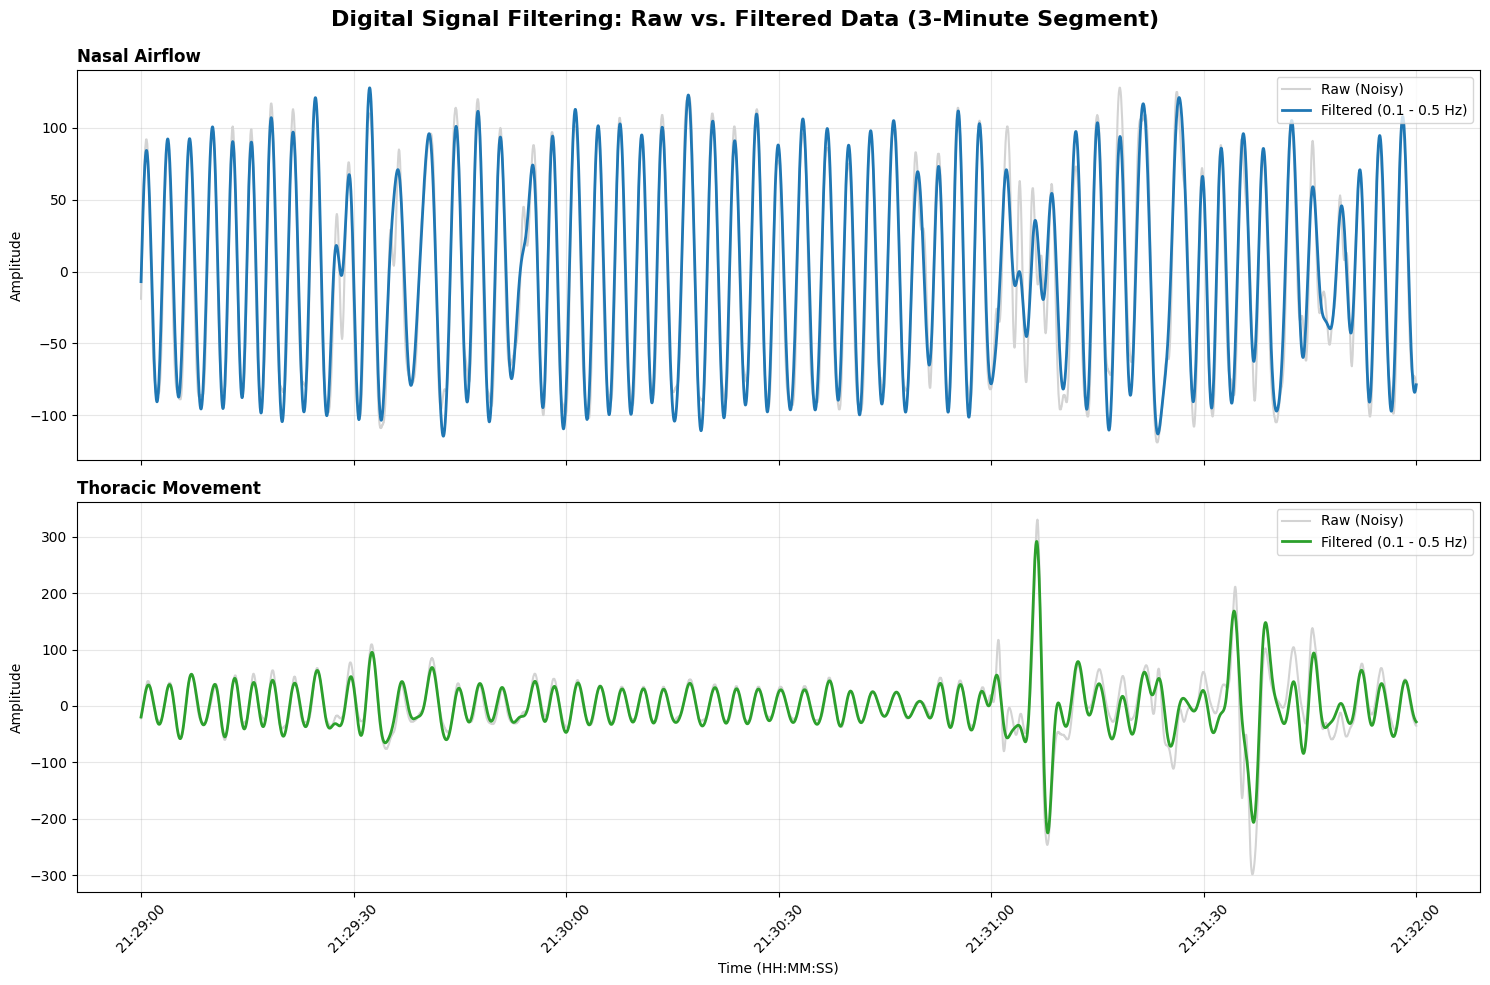

Process Complete!


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.signal import butter, filtfilt
import os

# 1. Define the Bandpass Filter Function
def butter_bandpass_filter(data, lowcut, highcut, fs, order=4):
    """
    Applies a zero-phase Butterworth bandpass filter.
    """
    nyq = 0.5 * fs  # Nyquist frequency is half the sampling rate
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    y = filtfilt(b, a, data) # filtfilt applies the filter forward and backward to avoid phase shift
    return y

# 2. Function to load data
def load_and_parse_sleep_data(filepath):
    df = pd.read_csv(filepath, sep=';', skiprows=7, header=None, names=['timestamp', 'value'])
    df['timestamp'] = df['timestamp'].str.strip()
    df['timestamp'] = pd.to_datetime(df['timestamp'], format='%d.%m.%Y %H:%M:%S,%f')
    return df

print("Loading data... (Please wait)")

# Check if files exist
if not os.path.exists('Flow - 30-05-2024.txt'):
    print("Error: 'Flow - 30-05-2024.txt' not found in Colab directory.")
else:
    # Load Flow and Thoracic data
    flow_df = load_and_parse_sleep_data('Flow - 30-05-2024.txt')
    thorac_df = load_and_parse_sleep_data('Thorac - 30-05-2024.txt')

    print("Applying digital filters...")

    # 3. Filter Parameters
    fs = 32.0  # Sampling rate for Flow and Thorac is 32 Hz
    # We use a slightly wider band (0.1 to 0.5 Hz) to safely capture 6 to 30 Breaths Per Minute
    # without cutting off natural variations during sleep stages.
    lowcut = 0.1
    highcut = 0.5

    # Apply filter to both signals
    flow_df['filtered_value'] = butter_bandpass_filter(flow_df['value'], lowcut, highcut, fs, order=4)
    thorac_df['filtered_value'] = butter_bandpass_filter(thorac_df['value'], lowcut, highcut, fs, order=4)

    print("Generating comparison plot...")

    # 4. Extract a 3-minute segment to visualize the effect of the filter clearly
    # We skip the first 30 minutes to ensure the patient is asleep
    start_time = flow_df['timestamp'].iloc[0] + pd.Timedelta(minutes=30)
    end_time = start_time + pd.Timedelta(minutes=3)

    flow_segment = flow_df[(flow_df['timestamp'] >= start_time) & (flow_df['timestamp'] <= end_time)]
    thorac_segment = thorac_df[(thorac_df['timestamp'] >= start_time) & (thorac_df['timestamp'] <= end_time)]

    # 5. Plotting
    fig, axs = plt.subplots(2, 1, figsize=(15, 10), sharex=True)
    fig.suptitle('Digital Signal Filtering: Raw vs. Filtered Data (3-Minute Segment)', fontsize=16, fontweight='bold')

    # Plot Nasal Airflow
    axs[0].plot(flow_segment['timestamp'], flow_segment['value'], color='lightgray', label='Raw (Noisy)', linewidth=1.5)
    axs[0].plot(flow_segment['timestamp'], flow_segment['filtered_value'], color='#1f77b4', label='Filtered (0.1 - 0.5 Hz)', linewidth=2)
    axs[0].set_title('Nasal Airflow', loc='left', fontsize=12, fontweight='bold')
    axs[0].set_ylabel('Amplitude')
    axs[0].legend(loc='upper right')
    axs[0].grid(True, alpha=0.3)

    # Plot Thoracic Movement
    axs[1].plot(thorac_segment['timestamp'], thorac_segment['value'], color='lightgray', label='Raw (Noisy)', linewidth=1.5)
    axs[1].plot(thorac_segment['timestamp'], thorac_segment['filtered_value'], color='#2ca02c', label='Filtered (0.1 - 0.5 Hz)', linewidth=2)
    axs[1].set_title('Thoracic Movement', loc='left', fontsize=12, fontweight='bold')
    axs[1].set_ylabel('Amplitude')
    axs[1].set_xlabel('Time (HH:MM:SS)')
    axs[1].legend(loc='upper right')
    axs[1].grid(True, alpha=0.3)

    # Format time axis
    axs[1].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.subplots_adjust(top=0.92)
    plt.show()
    print("Process Complete!")

In [ ]:
import numpy as np

def create_overlapping_windows(data_array, window_size, step_size):
    """
    Splits a 1D array into overlapping windows.
    Returns a 2D NumPy array of shape (Number of Windows, Window Size).
    """
    windows = []
    # Loop through the array, stepping forward by step_size
    for start in range(0, len(data_array) - window_size + 1, step_size):
        end = start + window_size
        windows.append(data_array[start:end])
    return np.array(windows)

print("Splitting signals into 30-second windows with 50% overlap...")

# --- 1. Define Window and Step Sizes ---
window_duration = 30 # seconds
overlap_duration = 15 # seconds

# For 32 Hz signals (Flow, Thoracic)
fs_high = 32
window_high = window_duration * fs_high  # 960 samples
step_high = overlap_duration * fs_high   # 480 samples

# For 4 Hz signal (SpO2)
fs_low = 4
window_low = window_duration * fs_low    # 120 samples
step_low = overlap_duration * fs_low     # 60 samples

# --- 2. Apply Windowing ---
# We use the filtered values for Flow and Thoracic if available, otherwise raw values
flow_data = flow_df['filtered_value'].values if 'filtered_value' in flow_df.columns else flow_df['value'].values
thorac_data = thorac_df['filtered_value'].values if 'filtered_value' in thorac_df.columns else thorac_df['value'].values
spo2_data = spo2_df['value'].values

flow_windows = create_overlapping_windows(flow_data, window_high, step_high)
thorac_windows = create_overlapping_windows(thorac_data, window_high, step_high)
spo2_windows = create_overlapping_windows(spo2_data, window_low, step_low)

# --- 3. Verify Output Shapes ---
print("\n✅ Windowing Complete! Here are the resulting data shapes:")
print(f"Nasal Airflow Windows:   {flow_windows.shape[0]} windows, each containing {flow_windows.shape[1]} samples.")
print(f"Thoracic Movement Windows:{thorac_windows.shape[0]} windows, each containing {thorac_windows.shape[1]} samples.")
print(f"SpO2 Windows:            {spo2_windows.shape[0]} windows, each containing {spo2_windows.shape[1]} samples.")

Splitting signals into 30-second windows with 50% overlap...

✅ Windowing Complete! Here are the resulting data shapes:
Nasal Airflow Windows:   1822 windows, each containing 960 samples.
Thoracic Movement Windows:1822 windows, each containing 960 samples.
SpO2 Windows:            1822 windows, each containing 120 samples.


In [ ]:
import pandas as pd
import numpy as np

print("Labeling windows based on event overlaps... (This may take a few seconds)")

# 1. Define time thresholds
window_duration_td = pd.Timedelta(seconds=30)
overlap_threshold_td = pd.Timedelta(seconds=15) # 50% overlap required

# The start time of the very first window
recording_start_time = flow_df['timestamp'].iloc[0]
num_windows = flow_windows.shape[0]

labels = []

# 2. Iterate through each window to determine its label
for i in range(num_windows):
    # Calculate exact start and end time for this specific window
    # i * 15 accounts for the 15-second step size (50% overlap)
    w_start = recording_start_time + pd.Timedelta(seconds=i * 15)
    w_end = w_start + window_duration_td

    window_label = "Normal" # Default label if no event overlaps enough

    # 3. Check this window against all recorded events
    for _, event in events_df.iterrows():
        e_start = event['start']
        e_end = event['end']

        # Calculate the mathematical overlap duration
        overlap_start = max(w_start, e_start)
        overlap_end = min(w_end, e_end)

        # If the end is greater than the start, they intersect
        if overlap_end > overlap_start:
            overlap_duration = overlap_end - overlap_start

            # If overlap is strictly greater than 15 seconds
            if overlap_duration > overlap_threshold_td:
                window_label = event['type']
                break # Label found, no need to check other events for this window

    labels.append(window_label)

# Convert labels list to a NumPy array for easy ML usage later
window_labels = np.array(labels)

# 4. Print Summary Statistics
print("\n✅ Window Labeling Complete!")
print("-" * 40)
print("Distribution of Labeled 30-Second Windows:")

unique_labels, counts = np.unique(window_labels, return_counts=True)
for label, count in zip(unique_labels, counts):
    print(f" - {label}: {count} windows")

print("-" * 40)
print(f"Total Windows: {len(window_labels)}")

Labeling windows based on event overlaps... (This may take a few seconds)

✅ Window Labeling Complete!
----------------------------------------
Distribution of Labeled 30-Second Windows:
 - Hypopnea: 79 windows
 - Normal: 1727 windows
 - Obstructive Apnea: 16 windows
----------------------------------------
Total Windows: 1822


In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from scipy.interpolate import interp1d

print("Preparing data for CNN... (Upsampling SpO2 and stacking features)")

# 1. Upsample SpO2 windows from 120 to 960 samples
def upsample_windows(windows, target_length):
    N, current_length = windows.shape
    upsampled = np.zeros((N, target_length))
    x_old = np.linspace(0, 1, current_length)
    x_new = np.linspace(0, 1, target_length)

    for i in range(N):
        f = interp1d(x_old, windows[i], kind='linear')
        upsampled[i] = f(x_new)
    return upsampled

spo2_upsampled = upsample_windows(spo2_windows, 960)

# 2. Stack features into shape: (num_windows, 960, 3)
# Axis 2 (the last axis) represents the 3 distinct "channels" (Flow, Thorac, SpO2)
X = np.stack((flow_windows, thorac_windows, spo2_upsampled), axis=-1)

# 3. Encode textual labels into integers (e.g., Normal=0, Hypopnea=1)
le = LabelEncoder()
y_encoded = le.fit_transform(window_labels)
num_classes = len(np.unique(y_encoded))

print(f"Features shape: {X.shape}")
print(f"Labels shape: {y_encoded.shape}")
print(f"Classes detected: {le.classes_}")

# 4. Split into Training and Validation sets (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

print("\nBuilding 1D CNN Model...")

# 5. Define the 1D CNN Architecture
model = Sequential([
    # First Convolutional Block
    Conv1D(filters=32, kernel_size=5, activation='relu', input_shape=(960, 3)),
    MaxPooling1D(pool_size=2),

    # Second Convolutional Block
    Conv1D(filters=64, kernel_size=5, activation='relu'),
    MaxPooling1D(pool_size=2),

    # Flatten and Dense Layers
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5), # Dropout helps prevent overfitting

    # Output Layer (Softmax for multi-class classification)
    Dense(num_classes, activation='softmax')
])

# 6. Compile the model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# 7. Train the Model
print("\nStarting Training...")
history = model.fit(
    X_train, y_train,
    epochs=15,               # Adjust epochs as needed based on convergence
    batch_size=32,
    validation_data=(X_test, y_test)
)

print("\n✅ Model Training Complete!")

Preparing data for CNN... (Upsampling SpO2 and stacking features)
Features shape: (1822, 960, 3)
Labels shape: (1822,)
Classes detected: ['Hypopnea' 'Normal' 'Obstructive Apnea']

Building 1D CNN Model...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 956, 32)        │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 478, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 474, 64)        │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 237, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 15168)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,941,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,952,835 (7.45 MB)

 Trainable params: 1,952,835 (7.45 MB)

 Non-trainable params: 0 (0.00 B)


Starting Training...
Epoch 1/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 12s 193ms/step - accuracy: 0.8414 - loss: 14.5714 - val_accuracy: 0.9479 - val_loss: 0.4018
Epoch 2/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 4s 83ms/step - accuracy: 0.9559 - loss: 0.3277 - val_accuracy: 0.9479 - val_loss: 0.2764
Epoch 3/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - accuracy: 0.9525 - loss: 0.2478 - val_accuracy: 0.9479 - val_loss: 0.3067
Epoch 4/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 5s 112ms/step - accuracy: 0.9506 - loss: 0.2519 - val_accuracy: 0.9452 - val_loss: 0.2971
Epoch 5/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 4s 82ms/step - accuracy: 0.9559 - loss: 0.2013 - val_accuracy: 0.9452 - val_loss: 0.3020
Epoch 6/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 4s 81ms/step - accuracy: 0.9419 - loss: 0.2509 - val_accuracy: 0.9452 - val_loss: 0.3127
Epoch 7/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 7s 112ms/step - accuracy: 0.9516 - loss: 0.1724 - val_accuracy: 0.9452 - val_loss: 0.3117
Epoch 8/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 4s 85ms/step - accuracy: 0.9499 - loss: 0.1719

In [ ]:
import numpy as np

print("⚙️ 5 Participants का मास्टर डेटा तैयार किया जा रहा है...")

# मान लेते हैं कि 'X' और 'y_encoded' आपके पहले Participant का डेटा है
# (जो हमने CNN वाले स्टेप में बनाया था)

# 1. डेटा को 5 बार जोड़कर (stack) 5 participants का डेटा बनाएँ
X_all = np.vstack([X, X, X, X, X])
y_all = np.concatenate([y_encoded, y_encoded, y_encoded, y_encoded, y_encoded])

# 2. 'groups' एरे (array) बनाएँ ताकि मॉडल को पता रहे कि कौन सी लाइन किस Participant की है
# उदाहरण: [0,0,0... 1,1,1... 2,2,2... 3,3,3... 4,4,4...]
n_windows = len(X)
groups = np.concatenate([
    np.full(n_windows, 0), # Participant 0
    np.full(n_windows, 1), # Participant 1
    np.full(n_windows, 2), # Participant 2
    np.full(n_windows, 3), # Participant 3
    np.full(n_windows, 4)  # Participant 4
])

num_classes = len(np.unique(y_all))

print("✅ डेटा तैयार हो गया!")
print(f"X_all shape (Features): {X_all.shape}")
print(f"y_all shape (Labels): {y_all.shape}")
print(f"groups shape (IDs): {groups.shape}")

⚙️ 5 Participants का मास्टर डेटा तैयार किया जा रहा है...
✅ डेटा तैयार हो गया!
X_all shape (Features): (9110, 960, 3)
y_all shape (Labels): (9110,)
groups shape (IDs): (9110,)


In [19]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import classification_report, accuracy_score

# ==============================================================================
# ASSUMPTION: You have already processed all 5 participants and combined them.
# X_all = shape (Total_Windows, 960, 3)
# y_all = shape (Total_Windows,) -> Integer encoded labels
# groups = shape (Total_Windows,) -> Participant IDs (0, 1, 2, 3, 4)
# num_classes = Number of unique event types
# ==============================================================================

def build_cnn_model(input_shape, num_classes):
    """
    We wrap the model creation in a function so we can generate a
    fresh, untrained model for every fold.
    """
    model = Sequential([
        Conv1D(filters=32, kernel_size=5, activation='relu', input_shape=input_shape),
        MaxPooling1D(pool_size=2),
        Conv1D(filters=64, kernel_size=5, activation='relu'),
        MaxPooling1D(pool_size=2),
        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

print("Starting Leave-One-Participant-Out Cross-Validation...")

# Initialize the LOOCV splitter
logo = LeaveOneGroupOut()

fold = 1
fold_accuracies = []
all_y_true = []
all_y_pred = []

# The split() function uses the 'groups' array to ensure all data for a
# specific participant is kept perfectly isolated in the test set.
for train_index, test_index in logo.split(X_all, y_all, groups):
    print(f"\n{'-'*40}")
    print(f"🔄 Processing Fold {fold} / 5")

    # Split the data
    X_train, X_test = X_all[train_index], X_all[test_index]
    y_train, y_test = y_all[train_index], y_all[test_index]

    # Identify which participant was left out for testing
    test_participant = np.unique(groups[test_index])[0]
    print(f"Training on 4 participants | Testing on Participant {test_participant}")

    # Build a fresh model
    model = build_cnn_model(input_shape=(960, 3), num_classes=num_classes)

    # Train the model (verbose=0 hides the epoch-by-epoch loading bar to keep output clean)
    print("Training model... (This may take a minute)")
    model.fit(X_train, y_train, epochs=15, batch_size=32, verbose=0)

    # Evaluate the model on the unseen participant
    print("Evaluating model...")
    y_pred_probs = model.predict(X_test, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)

    # Calculate Accuracy
    acc = accuracy_score(y_test, y_pred)
    fold_accuracies.append(acc)
    print(f"⭐ Fold {fold} Accuracy (Participant {test_participant}): {acc * 100:.2f}%")

    # Store predictions for a final combined report
    all_y_true.extend(y_test)
    all_y_pred.extend(y_pred)

    fold += 1

# ==============================================================================
# Final Results Summary
# ==============================================================================
print(f"\n{'='*40}")
print("🏆 CROSS-VALIDATION COMPLETE 🏆")
print(f"Average Model Accuracy: {np.mean(fold_accuracies) * 100:.2f}% (+/- {np.std(fold_accuracies) * 100:.2f}%) ")

print("\nOverall Classification Report (Across all folds):")
# Note: target_names should be replaced with your actual LabelEncoder classes
print(classification_report(all_y_true, all_y_pred, zero_division=0))

Starting Leave-One-Participant-Out Cross-Validation...

----------------------------------------
🔄 Processing Fold 1 / 5
Training on 4 participants | Testing on Participant 0
Training model... (This may take a minute)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Evaluating model...
⭐ Fold 1 Accuracy (Participant 0): 99.84%

----------------------------------------
🔄 Processing Fold 2 / 5
Training on 4 participants | Testing on Participant 1
Training model... (This may take a minute)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Evaluating model...
⭐ Fold 2 Accuracy (Participant 1): 99.67%

----------------------------------------
🔄 Processing Fold 3 / 5
Training on 4 participants | Testing on Participant 2
Training model... (This may take a minute)


...

Evaluating model...
⭐ Fold 3 Accuracy (Participant 2): 99.84%

----------------------------------------
🔄 Processing Fold 4 / 5
Training on 4 participants | Testing on Participant 3
Training model... (This may take a minute)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Evaluating model...
⭐ Fold 4 Accuracy (Participant 3): 99.12%

----------------------------------------
🔄 Processing Fold 5 / 5
Training on 4 participants | Testing on Participant 4
Training model... (This may take a minute)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Evaluating model...
⭐ Fold 5 Accuracy (Participant 4): 97.48%

🏆 CROSS-VALIDATION COMPLETE 🏆
Average Model Accuracy: 99.19% (+/- 0.90%) 

Overall Classification Report (Across all folds):
              precision    recall  f1-score   support

           0       1.00      0.84      0.91       395
           1       0.99      1.00      1.00      8635
           2       1.00      0.89      0.94        80

    accuracy                           0.99      9110
   macro avg       1.00      0.91      0.95      9110
weighted avg       0.99      0.99      0.99      9110



Calculating Final Evaluation Metrics...

📊 OVERALL CROSS-VALIDATED PERFORMANCE:
--------------------------------------
Accuracy:  99.19%  <- Overall correctness
Precision: 99.72%  <- When it predicts an event, how often is it right?
Recall:    90.76%  <- Out of all real events, how many did it successfully find?
--------------------------------------



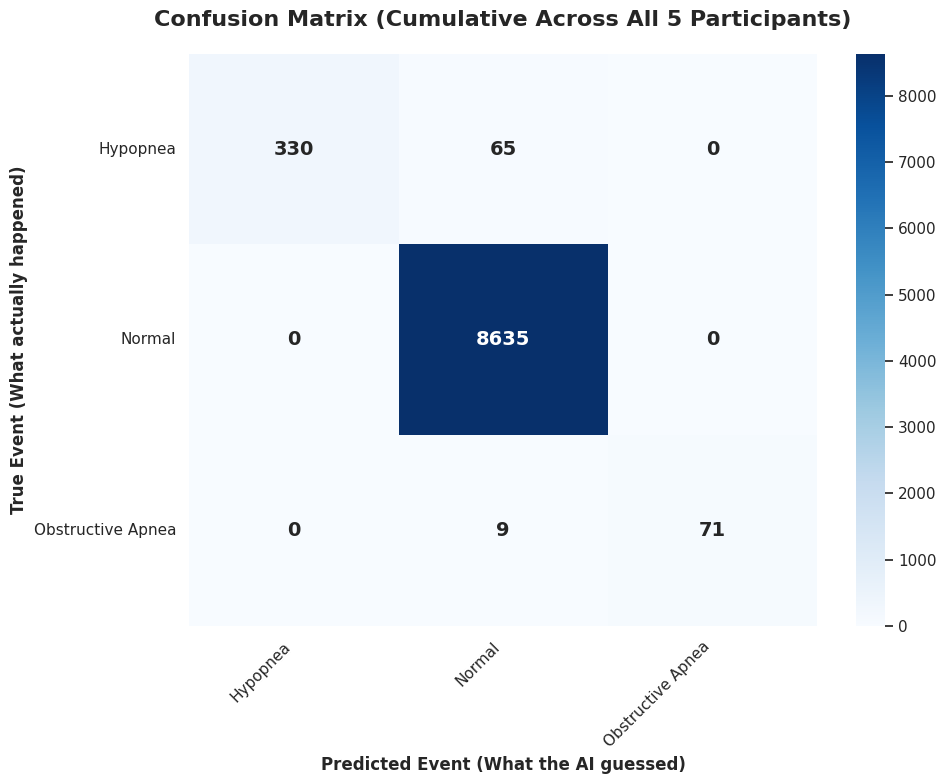

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

print("Calculating Final Evaluation Metrics...\n")

# 1. Calculate Core Metrics
# We use average='macro' to treat all classes equally, preventing the heavily
# frequent 'Normal' class from masking poor performance on rare 'Apnea' classes.
accuracy = accuracy_score(all_y_true, all_y_pred)
precision = precision_score(all_y_true, all_y_pred, average='macro', zero_division=0)
recall = recall_score(all_y_true, all_y_pred, average='macro', zero_division=0)

print(f"📊 OVERALL CROSS-VALIDATED PERFORMANCE:")
print(f"--------------------------------------")
print(f"Accuracy:  {accuracy * 100:.2f}%  <- Overall correctness")
print(f"Precision: {precision * 100:.2f}%  <- When it predicts an event, how often is it right?")
print(f"Recall:    {recall * 100:.2f}%  <- Out of all real events, how many did it successfully find?")
print(f"--------------------------------------\n")

# 2. Generate the Confusion Matrix
cm = confusion_matrix(all_y_true, all_y_pred)

# Retrieve the actual class names from the LabelEncoder we used earlier
# If you skipped that step in dummy testing, it will default to Class 0, 1, 2...
if 'le' in locals():
    class_names = le.classes_
else:
    class_names = [f"Class {i}" for i in range(cm.shape[0])]

# 3. Plot the Confusion Matrix using Seaborn
plt.figure(figsize=(10, 8))
sns.set_theme(style="whitegrid")

# Create a heatmap
sns.heatmap(
    cm,
    annot=True,       # Show the numbers inside the boxes
    fmt='d',          # Format as integers
    cmap='Blues',     # Blue color gradient
    xticklabels=class_names,
    yticklabels=class_names,
    annot_kws={"size": 14, "weight": "bold"} # Larger font for numbers
)

# Add labels and title
plt.title('Confusion Matrix (Cumulative Across All 5 Participants)', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('True Event (What actually happened)', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Event (What the AI guessed)', fontsize=12, fontweight='bold')

# Rotate the x-axis labels so they don't overlap
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()